# Weak Labels EDA

สำรวจ `data/weak_labels.csv` — เอาต์พุตจากระบบ tag rule ภายนอก ก่อนเข้าสู่ Task 4 (weak-label gating)

คอลัมน์: `content, flag, category, score, confidence, sell_intent, matched_keywords`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
%matplotlib inline

PATH = 'data/weak_labels.csv'  # รัน jupyter จาก project root (cwd = root)
df = pd.read_csv(PATH, encoding='utf-8-sig', low_memory=False)  # ไฟล์มี BOM
print(f'{len(df):,} rows')

258,136 rows


In [2]:
# รูปร่างข้อมูล
df.shape, list(df.columns)

((258136, 7),
 ['content',
  'flag',
  'category',
  'score',
  'confidence',
  'sell_intent',
  'matched_keywords'])

In [3]:
# missing value ต่อคอลัมน์
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'missing': missing, 'pct': missing_pct})

,missing,pct
content,1,0.0
flag,0,0.0
category,114583,44.4
score,0,0.0
confidence,0,0.0
sell_intent,116777,45.2
matched_keywords,88424,34.3


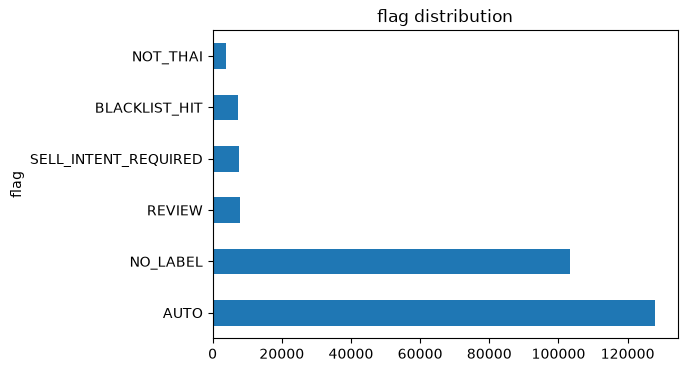

In [4]:
# flag = ป้ายจากระบบ tag rule (label จริง ๆ)
df['flag'].value_counts().plot(kind='barh', figsize=(6, 4), title='flag distribution')
plt.show()

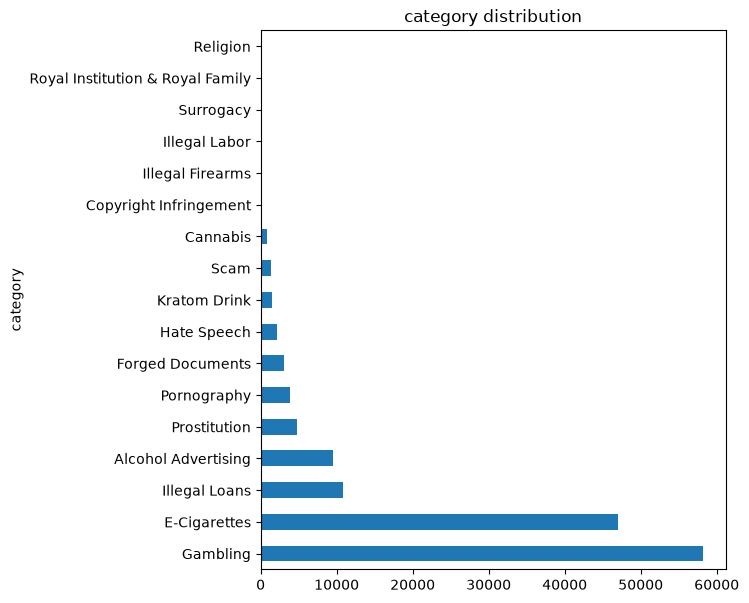

หมวดที่ไม่ใช่ NaN: 17 | NaN: 114,583


In [5]:
# category = 18 หมวด (AUTO/REVIEW/SELL_INTENT_REQUIRED เท่านั้นที่มีหมวด)
cat_counts = df['category'].value_counts()
cat_counts.head(20).plot(kind='barh', figsize=(6, 7), title='category distribution')
plt.show()
print(f'หมวดที่ไม่ใช่ NaN: {len(cat_counts)} | NaN: {df["category"].isna().sum():,}')

In [6]:
# confidence ตาม flag
pd.crosstab(df['flag'], df['confidence'], dropna=False)

confidence,high,low,medium,none
flag,,,,
AUTO,128050,0,0,0
BLACKLIST_HIT,0,0,0,7407
NOT_THAI,0,0,0,3835
NO_LABEL,0,47637,0,55704
REVIEW,0,0,7849,0
SELL_INTENT_REQUIRED,0,0,0,7654


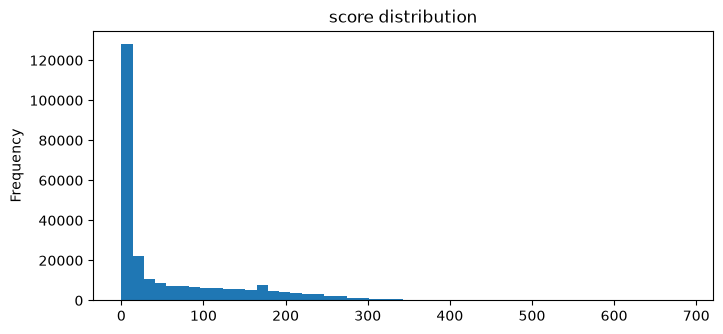

count    258136.000000
mean         61.462748
std          87.023581
min           0.000000
25%           0.000000
50%          14.100000
75%         103.250000
max         686.311446
Name: score, dtype: float64

In [7]:
# score — ระดับความแรงของ match
df['score'].plot(kind='hist', bins=50, figsize=(8, 3.5), title='score distribution')
plt.show()
df['score'].describe()

In [8]:
# sell_intent ตาม flag
pd.crosstab(df['flag'], df['sell_intent'], dropna=False)

sell_intent,False,True,NaN
flag,,,
AUTO,0,53781,74269
BLACKLIST_HIT,0,0,7407
NOT_THAI,0,0,3835
NO_LABEL,21436,56227,25678
REVIEW,0,2261,5588
SELL_INTENT_REQUIRED,7654,0,0


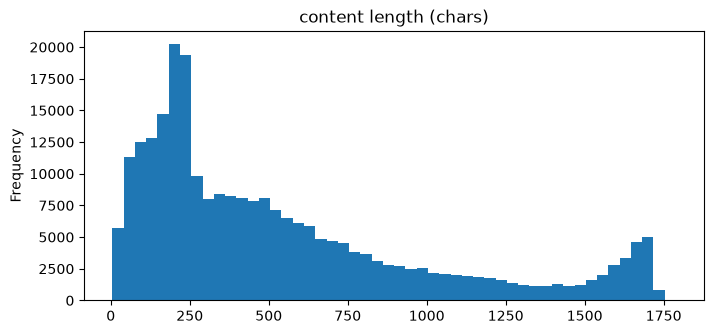

count    258135.000000
mean        540.205354
std         460.494387
min           5.000000
25%         196.000000
50%         388.000000
75%         744.000000
max        1789.000000
Name: content, dtype: float64

In [9]:
# ความยาว content
df['content'].str.len().plot(kind='hist', bins=50, figsize=(8, 3.5), title='content length (chars)')
plt.show()
df['content'].str.len().describe()

In [10]:
# keyword ที่ถูก match บ่อยสุด (flag = AUTO มีหมวดชัดเจน)
auto = df[df['flag'] == 'AUTO']
auto['matched_keywords'].value_counts().head(15)

matched_keywords
บาคาร่า|เครดิตฟรี|สล็อตแตก|โปรทุนน้อย|แตกง่าย|ทุนน้อยก็แตกได้|โปร|เครดิต|แจก|ฝาก|คืน|ยอด|ฟรี|ยอดเสีย|สล็อต|แตก|ปั่น|จริง    2305
ไอ้เขมร                                                                                                                     1578
โฉนด                                                                                                                        1551
#รับงาน|#ไซด์ไลน์|ไซด์ไลน์                                                                                                   959
#รับงาน                                                                                                                      906
ไซด์ไลน์                                                                                                                     786
ขายพอต|พอต|พอตใช้แล้วทิ้ง|มาโบ|#พอต                                                                                          584
#รับงาน|ไซด์ไลน์                                                                